# Praktikum Komputasi Numerik
## Modul 3: Solusi Persamaan Nirlanjar (Metode Tertutup dan Terbuka)

|  |  |
|---|---|
| Nama | Fathin Yassarahman |
| NIM | 241524041 |
| Kelas | 3B |
| Program Studi | D-4 Teknik Informatika |
| Jurusan | Teknik Komputer dan Informatika, Politeknik Negeri Bandung |
| Tanggal | 7 Oktober 2026 |

isi notebook: Task I sampai Task IV, jawaban Tugas Praktikum (III.8), dan Soal Latihan HOTS gaya ICPC (III.9).

fungsi uji yang dipakai sepanjang notebook adalah f(x) = x^3 - x - 2 dengan akar acuan x* = 1.5213797068045676, diperoleh dari Newton-Raphson pada Task III.

---
# Task 0: Setup Environment

memeriksa python, numpy, dan matplotlib sebelum masuk materi. seluruh metode pada modul ini cukup memakai `math`, sedangkan numpy dan matplotlib dipakai untuk gambar

In [1]:
print("Hello, Modul 3!")

import sys
print("Python version:", sys.version.split()[0])

import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
print("NumPy version     :", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Hello, Modul 3!
Python version: 3.13.16


NumPy version     : 2.5.3
Matplotlib version: 3.11.2


---
# Task I: Metode Bisection

mencari akar f(x) = x^3 - x - 2 dengan membelah dua interval [1, 2] berulang kali, lalu menguji apakah jumlah iterasinya bisa ditebak sebelum program dijalankan

In [2]:
# I.1 fungsi uji sepanjang modul dan pengecekan tanda di ujung interval [1, 2]
import math

f = lambda x: x**3 - x - 2
print("f(1) =", f(1))
print("f(2) =", f(2))
print("beda tanda?", f(1) * f(2) < 0)

f(1) = -2
f(2) = 4
beda tanda? True


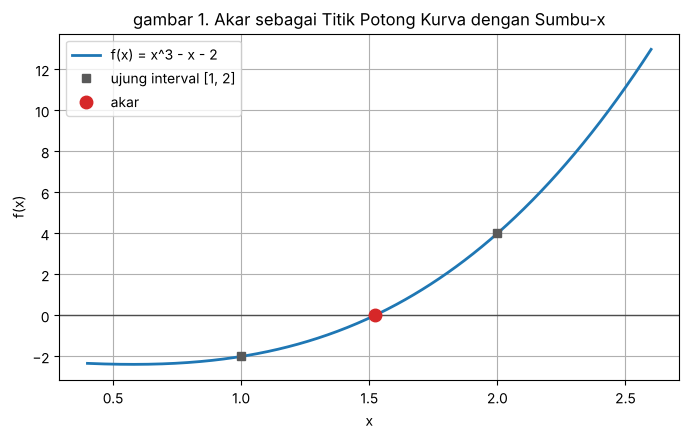

In [3]:
# I.2 gambar 1. akar sebagai titik potong kurva dengan sumbu-x
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0.4, 2.6, 400)
plt.figure(figsize=(8, 4.5))
plt.plot(xs, f(xs), lw=2, label="f(x) = x^3 - x - 2")
plt.axhline(0, color="0.3", lw=1)
plt.plot([1, 2], [f(1), f(2)], "s", color="0.35", label="ujung interval [1, 2]")
plt.plot([1.5213797], [0], "o", ms=9, color="tab:red", label="akar")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("gambar 1. Akar sebagai Titik Potong Kurva dengan Sumbu-x")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# I.3 bisection lengkap dengan tabel iterasi
def bisection(f, a, b, tol=1e-6, max_iter=100, cetak=True):
    """bisection dengan kriteria setengah lebar interval < tol. mengembalikan (akar, jumlah iterasi)."""
    if f(a) * f(b) > 0:
        raise ValueError("f(a) dan f(b) harus beda tanda")
    if cetak:
        print(f"{'i':>3} {'a':>12} {'c':>12} {'b':>12} {'f(c)':>13} {'lebar':>11}")
    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        if cetak:
            print(f"{i:>3} {a:>12.7f} {c:>12.7f} {b:>12.7f} {fc:>13.3e} {b - a:>11.7f}")
        if fc == 0 or (b - a) / 2 < tol:
            return c, i
        if f(a) * fc < 0:
            b = c          # akar di kiri
        else:
            a = c          # akar di kanan
    return c, max_iter

akar_bis, n_bis = bisection(f, 1, 2, tol=1e-6)
print("akar      =", akar_bis)
print("f(akar)   =", f(akar_bis))
print("iterasi   =", n_bis)

  i            a            c            b          f(c)       lebar
  1    1.0000000    1.5000000    2.0000000    -1.250e-01   1.0000000
  2    1.5000000    1.7500000    2.0000000     1.609e+00   0.5000000
  3    1.5000000    1.6250000    1.7500000     6.660e-01   0.2500000
  4    1.5000000    1.5625000    1.6250000     2.522e-01   0.1250000
  5    1.5000000    1.5312500    1.5625000     5.911e-02   0.0625000
  6    1.5000000    1.5156250    1.5312500    -3.405e-02   0.0312500
  7    1.5156250    1.5234375    1.5312500     1.225e-02   0.0156250
  8    1.5156250    1.5195312    1.5234375    -1.097e-02   0.0078125
  9    1.5195312    1.5214844    1.5234375     6.222e-04   0.0039062
 10    1.5195312    1.5205078    1.5214844    -5.179e-03   0.0019531
 11    1.5205078    1.5209961    1.5214844    -2.279e-03   0.0009766
 12    1.5209961    1.5212402    1.5214844    -8.289e-04   0.0004883
 13    1.5212402    1.5213623    1.5214844    -1.034e-04   0.0002441
 14    1.5213623    1.5214233    1

interval setelah 8 iterasi: [1.5195312, 1.5234375], lebar 0.0039062


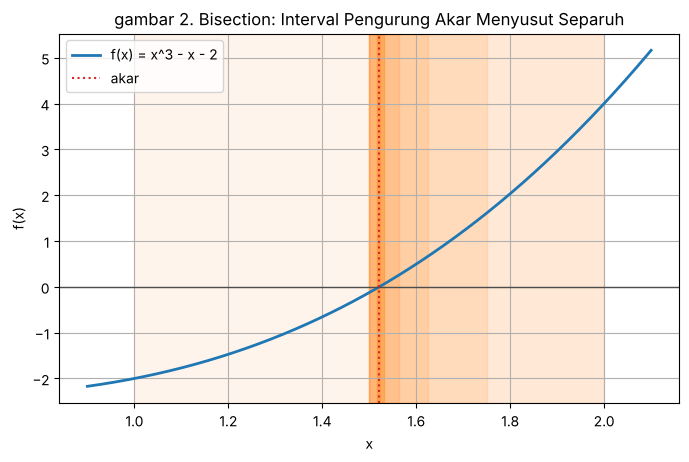

In [5]:
# I.4 gambar 2. interval pengurung akar menyusut separuh tiap iterasi
xs = np.linspace(0.9, 2.1, 400)
plt.figure(figsize=(8, 4.8))
plt.plot(xs, f(xs), lw=2, label="f(x) = x^3 - x - 2")
plt.axhline(0, color="0.3", lw=1)
a, b = 1.0, 2.0
for i in range(8):
    c = (a + b) / 2
    plt.axvspan(a, b, color="tab:orange", alpha=0.08 + 0.02 * i)
    if f(a) * f(c) < 0:
        b = c
    else:
        a = c
print(f"interval setelah 8 iterasi: [{a:.7f}, {b:.7f}], lebar {b - a:.7f}")
plt.axvline(1.5213797, color="tab:red", ls=":", label="akar")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("gambar 2. Bisection: Interval Pengurung Akar Menyusut Separuh")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# I.5 prediksi jumlah iterasi sebelum eksekusi: n = ceil(log2((b - a) / tol))
print(f"{'tol':>8}{'prediksi':>10}{'aktual':>9}{'|akar - x*|':>16}{'batas (b-a)/2^n':>18}")
print("-" * 61)
x_ref = 1.5213797068045676      # akar acuan dari Newton pada Task III
for tol in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    pred = math.ceil(math.log2((2 - 1) / tol))
    c, n = bisection(f, 1, 2, tol=tol, cetak=False)
    print(f"{tol:>8.0e}{pred:>10}{n:>9}{abs(c - x_ref):>16.3e}{(2 - 1) / 2**n:>18.3e}")
print("-" * 61)

     tol  prediksi   aktual     |akar - x*|   batas (b-a)/2^n
-------------------------------------------------------------
   1e-02         7        7       2.058e-03         7.812e-03
   1e-04        14       14       4.363e-05         6.104e-05
   1e-06        20       20       7.177e-07         9.537e-07
   1e-08        27       27       5.011e-09         7.451e-09
   1e-10        34       34       5.269e-11         5.821e-11
-------------------------------------------------------------


### lesson learnt task I

1. kolom lebar pada tabel iterasi terpangkas tepat separuh tiap baris, dari 1.0000000 pada iterasi 1 sampai 0.0000019 pada iterasi 20. sebaliknya, nilai f(c) tidak turun teratur: pada iterasi 9 nilainya 6.222e-04, lalu pada iterasi 10 justru membesar ke -5.179e-03. jadi untuk bisection, ukuran kemajuan yang dapat dipegang adalah lebar interval, bukan besar f(c)

2. prediksi n = ceil(log2((b - a)/tol)) cocok dengan jumlah iterasi aktual pada kelima toleransi yang diuji, yaitu 7, 14, 20, 27, dan 34. pada kelima baris itu galat aktualnya juga berada di bawah batas (b - a)/2^n, misalnya pada tol = 1e-6 galatnya 7.177e-07 terhadap batas 9.537e-07. bisection hanya membaca tanda f, sehingga jumlah iterasinya tidak dipengaruhi bentuk kurva

3. pada gambar 2, delapan iterasi pertama mempersempit wilayah pencarian dari [1, 2] menjadi [1.5195312, 1.5234375] dengan lebar 0.0039062. hasil akhir pada tol = 1e-6 memberi f(akar) = 4.27e-06, lebih besar daripada galat posisinya (7.18e-07). selisih ini sesuai dengan kemiringan kurva di akar, f'(x*) = 3(1.5214)^2 - 1 = 5.94, sehingga galat posisi sekecil apa pun terlihat sekitar enam kali lebih besar pada nilai f

---
# Task II: Metode Regula Falsi

titik tengah bisection diganti titik potong garis hubung antara (a, f(a)) dan (b, f(b)) dengan sumbu-x. kolom a dan b ikut dicetak untuk melihat ujung mana yang bergerak

In [7]:
# II.1 regula falsi, kolom a dan b ikut dicetak untuk melihat ujung mana yang bergerak
def regula_falsi(f, a, b, tol=1e-6, max_iter=200, cetak=True):
    """regula falsi dengan kriteria |f(c)| < tol. mengembalikan (akar, jumlah iterasi)."""
    if cetak:
        print(f"{'i':>3} {'a':>13} {'c':>13} {'b':>6} {'f(c)':>12}")
    for i in range(1, max_iter + 1):
        c = b - f(b) * (b - a) / (f(b) - f(a))
        fc = f(c)
        if cetak:
            print(f"{i:>3} {a:>13.9f} {c:>13.9f} {b:>6.3f} {fc:>12.3e}")
        if abs(fc) < tol:
            return c, i
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    return c, max_iter

akar_rf, n_rf = regula_falsi(f, 1, 2, tol=1e-6)
print("akar    =", akar_rf)
print("iterasi =", n_rf)

  i             a             c      b         f(c)
  1   1.000000000   1.333333333  2.000   -9.630e-01
  2   1.333333333   1.462686567  2.000   -3.333e-01
  3   1.462686567   1.504019004  2.000   -1.018e-01
  4   1.504019004   1.516330565  2.000   -2.989e-02
  5   1.516330565   1.519918550  2.000   -8.675e-03
  6   1.519918550   1.520957481  2.000   -2.509e-03
  7   1.520957481   1.521257749  2.000   -7.248e-04
  8   1.521257749   1.521344484  2.000   -2.093e-04
  9   1.521344484   1.521369535  2.000   -6.046e-05
 10   1.521369535   1.521376769  2.000   -1.746e-05
 11   1.521376769   1.521378858  2.000   -5.043e-06
 12   1.521378858   1.521379462  2.000   -1.456e-06
 13   1.521379462   1.521379636  2.000   -4.206e-07
akar    = 1.5213796360454928
iterasi = 13


In [8]:
# II.2 seberapa cepat lebar bracket menyusut: regula falsi dibanding bisection
def lebar_regula_falsi(f, a, b, n):
    """lebar interval [a, b] setelah tiap iterasi regula falsi."""
    lebar = []
    for _ in range(n):
        c = b - f(b) * (b - a) / (f(b) - f(a))
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
        lebar.append(b - a)
    return lebar

lb = lebar_regula_falsi(f, 1, 2, 13)
print(f"{'i':>3}{'lebar regula falsi':>20}{'lebar bisection':>18}")
for i in [1, 2, 5, 10, 13]:
    print(f"{i:>3}{lb[i - 1]:>20.7f}{1 / 2**i:>18.7f}")

  i  lebar regula falsi   lebar bisection
  1           0.6666667         0.5000000
  2           0.5373134         0.2500000
  5           0.4800814         0.0312500
 10           0.4786232         0.0009766
 13           0.4786204         0.0001221


In [9]:
# II.3 varian Illinois: nilai f di ujung yang macet dibagi dua supaya ujung itu ikut bergerak
def illinois(f, a, b, tol=1e-6, max_iter=200):
    fa, fb = f(a), f(b)
    sisi = 0
    for i in range(1, max_iter + 1):
        c = b - fb * (b - a) / (fb - fa)
        fc = f(c)
        if abs(fc) < tol:
            return c, i
        if fa * fc < 0:
            b, fb = c, fc
            if sisi == -1:
                fa /= 2           # ujung a macet dua kali berturut-turut
            sisi = -1
        else:
            a, fa = c, fc
            if sisi == 1:
                fb /= 2           # ujung b macet dua kali berturut-turut
            sisi = 1
    return c, max_iter

for tol in [1e-6, 1e-8, 1e-12]:
    _, n1 = regula_falsi(f, 1, 2, tol=tol, cetak=False)
    _, n2 = illinois(f, 1, 2, tol=tol)
    print(f"tol = {tol:.0e}   regula falsi: {n1:>3} iterasi   Illinois: {n2:>3} iterasi")

tol = 1e-06   regula falsi:  13 iterasi   Illinois:   7 iterasi
tol = 1e-08   regula falsi:  17 iterasi   Illinois:   7 iterasi
tol = 1e-12   regula falsi:  24 iterasi   Illinois:   8 iterasi


### lesson learnt task II

1. regula falsi selesai dalam 13 iterasi untuk |f(c)| < 1e-6 dengan akar 1.5213796360454928, sedangkan bisection pada Task I butuh 20 iterasi. perbandingan ini tidak sepenuhnya setara karena kriteria berhentinya berbeda: bisection memakai lebar interval, regula falsi memakai nilai f

2. ketiga belas nilai f(c) bernilai negatif dan kolom b bertahan di 2.000 dari baris pertama sampai terakhir. akibatnya lebar bracket berhenti di sekitar 0.4786 (0.4786204 pada iterasi 13), sementara lebar bisection pada iterasi yang sama sudah 0.0001221. karena itu lebar interval regula falsi tidak bisa dipakai sebagai jaminan posisi akar, dan kriteria berhentinya harus memakai |f(c)|. pada f(x) = x^3 - x - 2 kurvanya cembung di [1, 2], sehingga pada ketiga belas iterasi garis hubungnya memotong sumbu-x di sebelah kiri akar

3. saya mencoba varian Illinois yang disebut modul: bila ujung yang sama tertahan dua kali berturut-turut, nilai f pada ujung itu dibagi dua. hasilnya 7 iterasi untuk tol = 1e-6, 7 iterasi untuk 1e-8, dan 8 iterasi untuk 1e-12, dibandingkan 13, 17, dan 24 iterasi pada regula falsi biasa. perubahannya hanya dua baris, tetapi ujung yang macet ikut bergerak lagi

---
# Task III: Newton-Raphson dan Secant

dua metode terbuka yang tidak memerlukan interval pengurung. Newton memakai turunan analitik f'(x) = 3x^2 - 1, sedangkan secant memperkirakan kemiringan dari dua titik terakhir. orde konvergensinya diukur langsung dari data galat

In [10]:
# III.1 Newton-Raphson dengan turunan analitik f'(x) = 3x^2 - 1
df = lambda x: 3 * x**2 - 1

def newton(f, df, x0, tol=1e-8, max_iter=50, cetak=True):
    """mengembalikan (akar, jumlah baris tercetak); baris pertama adalah tebakan awal."""
    if cetak:
        print("Newton-Raphson:")
        print(f"{'i':>3} {'x':>16} {'f(x)':>13}")
    x = x0
    for i in range(1, max_iter + 1):
        fx = f(x)
        if cetak:
            print(f"{i:>3} {x:>16.10f} {fx:>13.3e}")
        if abs(fx) < tol:
            return x, i
        x = x - fx / df(x)
    return x, max_iter

akar_nr, n_nr = newton(f, df, 1.5)
print("akar =", akar_nr)

Newton-Raphson:
  i                x          f(x)
  1     1.5000000000    -1.250e-01
  2     1.5217391304     2.137e-03
  3     1.5213798060     5.894e-07
  4     1.5213797068     4.530e-14
akar = 1.5213797068045751


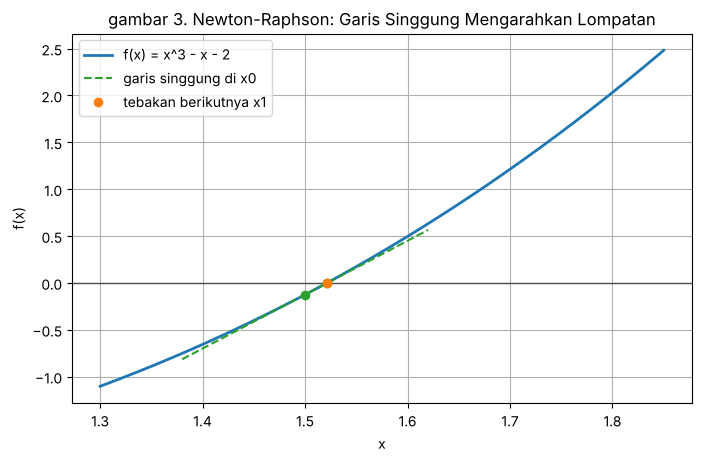

x0 = 1.5, x1 = 1.5217391304


In [11]:
# III.2 gambar 3. garis singgung mengarahkan lompatan Newton
xs = np.linspace(1.30, 1.85, 400)
plt.figure(figsize=(8, 4.8))
plt.plot(xs, f(xs), lw=2, label="f(x) = x^3 - x - 2")
plt.axhline(0, color="0.3", lw=1)
x0 = 1.5
x1 = x0 - f(x0) / df(x0)
tang = np.linspace(1.38, 1.62, 50)
plt.plot(tang, f(x0) + df(x0) * (tang - x0), "--", color="tab:green", label="garis singgung di x0")
plt.plot([x0, x1], [f(x0), 0], "o", color="tab:green")
plt.plot([x1], [f(x1)], "o", color="tab:orange", label="tebakan berikutnya x1")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("gambar 3. Newton-Raphson: Garis Singgung Mengarahkan Lompatan")
plt.legend()
plt.grid(True)
plt.show()
print(f"x0 = {x0}, x1 = {x1:.10f}")

In [12]:
# III.3 secant: kemiringan diperkirakan dari dua titik terakhir
def secant(f, x0, x1, tol=1e-8, max_iter=50, cetak=True):
    """mengembalikan (akar, jumlah iterasi)."""
    if cetak:
        print("Secant:")
        print(f"{'i':>3} {'x':>16} {'f(x)':>13}")
    fx0, fx1 = f(x0), f(x1)
    for i in range(1, max_iter + 1):
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        fx2 = f(x2)                          # satu evaluasi f baru per iterasi
        if cetak:
            print(f"{i:>3} {x2:>16.10f} {fx2:>13.3e}")
        if abs(fx2) < tol:
            return x2, i
        x0, fx0, x1, fx1 = x1, fx1, x2, fx2
    return x2, max_iter

akar_sc, n_sc = secant(f, 1.0, 2.0)
print("akar =", akar_sc)

Secant:
  i                x          f(x)
  1     1.3333333333    -9.630e-01
  2     1.4626865672    -3.333e-01
  3     1.5311694321     5.863e-02
  4     1.5209264205    -2.693e-03
  5     1.5213763167    -2.015e-05
  6     1.5213797080     7.015e-09
akar = 1.5213797079848717


In [13]:
# III.4 orde konvergensi dari data: p = ln(e_(i+1)/e_i) / ln(e_i/e_(i-1))
x_star = 1.5213797068045676

def jejak_newton(f, df, x0, n):
    xs = [x0]
    for _ in range(n):
        xs.append(xs[-1] - f(xs[-1]) / df(xs[-1]))
    return xs

def jejak_secant(f, x0, x1, n):
    xs = [x0, x1]
    for _ in range(n):
        a, b = xs[-2], xs[-1]
        xs.append(b - f(b) * (b - a) / (f(b) - f(a)))
    return xs

def tabel_orde(nama, xs):
    e = [abs(x - x_star) for x in xs]
    e = [v for v in e if v > 1e-15]          # buang galat yang sudah di bawah presisi float
    print(nama)
    print(f"{'i':>3}{'galat e_i':>14}{'orde p':>10}")
    for i, v in enumerate(e):
        p = math.log(e[i] / e[i - 1]) / math.log(e[i - 1] / e[i - 2]) if i >= 2 else float("nan")
        print(f"{i:>3}{v:>14.3e}{p:>10.3f}")
    print()

tabel_orde("Newton (x0 = 1.5)", jejak_newton(f, df, 1.5, 4))
tabel_orde("Newton (x0 = 3.0)", jejak_newton(f, df, 3.0, 7))
tabel_orde("Secant (x0 = 1, x1 = 2)", jejak_secant(f, 1.0, 2.0, 7))

Newton (x0 = 1.5)
  i     galat e_i    orde p
  0     2.138e-02       nan
  1     3.594e-04       nan
  2     9.916e-08     2.006
  3     7.550e-15     2.000

Newton (x0 = 3.0)
  i     galat e_i    orde p
  0     1.479e+00       nan
  1     6.325e-01       nan
  2     1.805e-01     1.476
  3     2.087e-02     1.721
  4     3.270e-04     1.926
  5     8.208e-08     1.995
  6     5.107e-15     2.002

Secant (x0 = 1, x1 = 2)
  i     galat e_i    orde p
  0     5.214e-01       nan
  1     4.786e-01       nan
  2     1.880e-01    10.917
  3     5.869e-02     1.246
  4     9.790e-03     1.538
  5     4.533e-04     1.716
  6     3.390e-06     1.593
  7     1.180e-09     1.627
  8     3.109e-15     1.613



In [14]:
# III.5 biaya total: banyaknya evaluasi f dan f' sampai |f(x)| < 1e-8
class Hitung:
    """pembungkus fungsi yang mencatat berapa kali fungsi dipanggil."""
    def __init__(self, fn):
        self.fn, self.n = fn, 0
    def __call__(self, x):
        self.n += 1
        return self.fn(x)

hf, hdf = Hitung(f), Hitung(df)
newton(hf, hdf, 1.5, tol=1e-8, cetak=False)
print(f"Newton    : f dipanggil {hf.n:>2} kali, f' dipanggil {hdf.n} kali")

hf = Hitung(f)
secant(hf, 1.0, 2.0, tol=1e-8, cetak=False)
print(f"Secant    : f dipanggil {hf.n:>2} kali")

hf = Hitung(f)
bisection(hf, 1, 2, tol=1e-8, cetak=False)
print(f"Bisection : f dipanggil {hf.n:>2} kali")

Newton    : f dipanggil  4 kali, f' dipanggil 3 kali
Secant    : f dipanggil  8 kali
Bisection : f dipanggil 55 kali


### lesson learnt task III

1. galat Newton dari x0 = 1.5 turun 2.138e-02, 3.594e-04, 9.916e-08, lalu 7.550e-15. jumlah digit benarnya kira-kira 2, 3, 7, dan 14, berlipat dua tiap pembaruan. orde yang dihitung dari data adalah 2.006 dan 2.000, sesuai konvergensi kuadratik pada modul. secant dari x0 = 1, x1 = 2 selesai dalam 6 iterasi, dan ordenya mendekati 1.618: nilai terakhirnya 1.593, 1.627, dan 1.613

2. orde 2 baru tampak setelah tebakan cukup dekat ke akar. dengan x0 = 3.0, orde Newton terukur 1.476, 1.721, 1.926, lalu 1.995 dan 2.002. hal serupa terjadi pada secant: nilai 10.917 pada baris awal tidak bermakna karena galat di dua titik awal (5.214e-01 dan 4.786e-01) masih hampir sama besar. untuk membaca orde, yang dipakai adalah baris-baris terakhir sebelum galat menyentuh presisi float

3. dari sisi biaya, sampai |f(x)| < 1e-8 Newton memanggil f 4 kali dan f' 3 kali, secant memanggil f 8 kali, dan bisection 55 kali. angka 55 itu sebagian berasal dari implementasi modul yang menghitung ulang f(a) tiap iterasi; bila f(a) disimpan, bisection cukup 29 evaluasi. bila f' sama mahalnya dengan f, total Newton (7) dan secant (8) hampir sama, sehingga secant layak dipilih ketika turunan sulit diturunkan. gambar 3 memperlihatkan satu lompatan garis singgung dari 1.5 ke 1.5217391304

---
# Task IV: Fixed Point dan Perbandingan Konvergensi

metode kelima, iterasi titik tetap dengan g(x) = (x + 2)^(1/3), lalu kelima metode dijalankan pada toleransi 1e-8 dan dibandingkan jumlah iterasi serta laju penurunan galatnya

In [15]:
# IV.1 iterasi titik tetap dengan g(x) = (x + 2)^(1/3)
def fixed_point(g, x0, tol=1e-8, max_iter=200, cetak=True):
    """kriteria |x_baru - x| < tol. mengembalikan (akar, jumlah iterasi)."""
    if cetak:
        print(f"{'i':>3} {'x':>16} {'|dx|':>11}")
    x = x0
    for i in range(1, max_iter + 1):
        x_baru = g(x)
        if cetak:
            print(f"{i:>3} {x_baru:>16.10f} {abs(x_baru - x):>11.3e}")
        if abs(x_baru - x) < tol:
            return x_baru, i
        x = x_baru
    return x, max_iter

g = lambda x: (x + 2) ** (1 / 3)
akar_fp, n_fp = fixed_point(g, 1.0)
print("akar (konvergen) =", akar_fp)

  i                x        |dx|
  1     1.4422495703   4.422e-01
  2     1.5098974493   6.765e-02
  3     1.5197243050   9.827e-03
  4     1.5211412691   1.417e-03
  5     1.5213453678   2.041e-04
  6     1.5213747615   2.939e-05
  7     1.5213789946   4.233e-06
  8     1.5213796042   6.096e-07
  9     1.5213796920   8.779e-08
 10     1.5213797047   1.264e-08
 11     1.5213797065   1.821e-09
akar (konvergen) = 1.5213797064982224


In [16]:
# IV.2 syarat |g'(x*)| < 1 dan rasio galat antar iterasi
dg = lambda x: (1 / 3) * (x + 2) ** (-2 / 3)
print(f"g'(x*) = {dg(x_star):.6f}")

xs = [1.0]
for _ in range(10):
    xs.append(g(xs[-1]))
e = [abs(x - x_star) for x in xs]
print(f"{'i':>3}{'galat e_i':>14}{'e_i / e_(i-1)':>16}")
for i in range(1, 11):
    print(f"{i:>3}{e[i]:>14.3e}{e[i] / e[i - 1]:>16.6f}")

# bentuk lain dari persamaan yang sama: x = x^3 - 2
g2 = lambda x: x**3 - 2
print()
print(f"bentuk lain g2(x) = x^3 - 2, |g2'(x*)| = {3 * x_star**2:.4f}")
x = 1.5
for i in range(1, 6):
    x = g2(x)
    print(f"  iterasi {i}: x = {x:.6g}")

g'(x*) = 0.144014
  i     galat e_i   e_i / e_(i-1)
  1     7.913e-02        0.151771
  2     1.148e-02        0.145106
  3     1.655e-03        0.144170
  4     2.384e-04        0.144036
  5     3.434e-05        0.144017
  6     4.945e-06        0.144014
  7     7.122e-07        0.144014
  8     1.026e-07        0.144014
  9     1.477e-08        0.144014
 10     2.127e-09        0.144014

bentuk lain g2(x) = x^3 - 2, |g2'(x*)| = 6.9438
  iterasi 1: x = 1.375
  iterasi 2: x = 0.599609
  iterasi 3: x = -1.78442
  iterasi 4: x = -7.68188
  iterasi 5: x = -455.318


In [17]:
# IV.3 tabel 6. perbandingan jumlah iterasi kelima metode, toleransi 1e-8
tol = 1e-8
hasil = [
    ("Bisection",      "lebar/2 < 1e-8", bisection(f, 1, 2, tol=tol, cetak=False)),
    ("Regula falsi",   "|f(c)| < 1e-8",  regula_falsi(f, 1, 2, tol=tol, cetak=False)),
    ("Fixed point",    "|dx| < 1e-8",    fixed_point(g, 1.0, tol=tol, cetak=False)),
    ("Secant",         "|f(x)| < 1e-8",  secant(f, 1.0, 2.0, tol=tol, cetak=False)),
    ("Newton-Raphson", "|f(x)| < 1e-8",  newton(f, df, 1.5, tol=tol, cetak=False)),
]
print(f"{'metode':<16}{'kriteria':<17}{'iterasi':>8}{'akar':>16}{'|akar - x*|':>14}")
print("-" * 71)
for nama, krit, (akar, n) in hasil:
    print(f"{nama:<16}{krit:<17}{n:>8}{akar:>16.10f}{abs(akar - x_star):>14.2e}")
print("-" * 71)

metode          kriteria          iterasi            akar   |akar - x*|
-----------------------------------------------------------------------
Bisection       lebar/2 < 1e-8         27    1.5213797018      5.01e-09
Regula falsi    |f(c)| < 1e-8          17    1.5213797063      4.92e-10
Fixed point     |dx| < 1e-8            11    1.5213797065      3.06e-10
Secant          |f(x)| < 1e-8           6    1.5213797080      1.18e-09
Newton-Raphson  |f(x)| < 1e-8           4    1.5213797068      7.55e-15
-----------------------------------------------------------------------


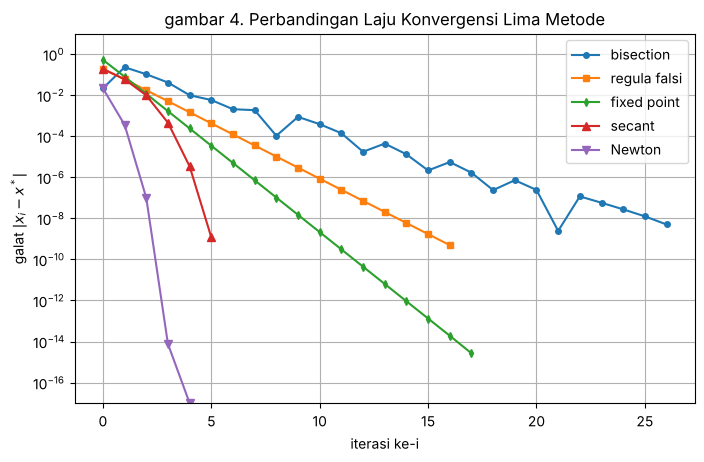

In [18]:
# IV.4 gambar 4. laju penurunan galat kelima metode terhadap x* (skala semilog)
def jejak_bis(f, a, b, n):
    xs = []
    for _ in range(n):
        c = (a + b) / 2
        xs.append(c)
        a, b = (a, c) if f(a) * f(c) < 0 else (c, b)
    return xs

def jejak_rf(f, a, b, n):
    xs = []
    for _ in range(n):
        c = b - f(b) * (b - a) / (f(b) - f(a))
        xs.append(c)
        a, b = (a, c) if f(a) * f(c) < 0 else (c, b)
    return xs

def jejak_fp(g, x0, n):
    xs = [x0]
    for _ in range(n):
        xs.append(g(xs[-1]))
    return xs

def galat(xs):
    # galat nol tidak bisa digambar pada skala log, diganti batas bawah 1e-17
    return [max(abs(x - x_star), 1e-17) for x in xs]

plt.figure(figsize=(8, 4.8))
plt.semilogy(galat(jejak_bis(f, 1, 2, 27)), "o-", ms=4, label="bisection")
plt.semilogy(galat(jejak_rf(f, 1, 2, 17)), "s-", ms=4, label="regula falsi")
plt.semilogy(galat(jejak_fp(g, 1.0, 17)), "d-", ms=4, label="fixed point")
plt.semilogy(galat(jejak_secant(f, 1.0, 2.0, 6)[2:]), "^-", label="secant")
plt.semilogy(galat(jejak_newton(f, df, 1.5, 4)), "v-", label="Newton")
plt.ylim(1e-17, 10)
plt.xlabel("iterasi ke-i")
plt.ylabel("galat $|x_i - x^*|$")
plt.title("gambar 4. Perbandingan Laju Konvergensi Lima Metode")
plt.legend()
plt.grid(True)
plt.show()

### lesson learnt task IV

1. iterasi titik tetap selesai dalam 11 iterasi dengan akar 1.5213797064982224. rasio galat e_i/e_(i-1) mendekati 0.144014 dan nilai itu sama dengan g'(x*) = 0.144014. jadi konvergensinya linear dengan konstanta |g'(x*)|, dan tiap iterasi memangkas galat menjadi sekitar 14 persen

2. persamaan yang sama bila ditulis x = x^3 - 2 memberi |g2'(x*)| = 6.9438, lebih besar dari 1. dari x0 = 1.5 iterasinya langsung menjauh: 1.375, 0.599609, -1.78442, -7.68188, dan -455.318 pada iterasi kelima. syarat |g'| < 1 pada modul terlihat berlaku di sini: g yang dipilih menentukan konvergen atau tidaknya, meski akarnya sama

3. tabel perbandingan memberi 27 (bisection), 17 (regula falsi), 11 (fixed point), 6 (secant), dan 4 (Newton) iterasi, sama dengan Tabel 6 modul. pada gambar 4, garis bisection bergerigi tetapi kemiringan rata-ratanya tetap, garis fixed point dan regula falsi lurus (linear), sedangkan Newton menukik paling tajam. meski begitu bisection tetap punya kelebihan: galat 5.01e-09 miliknya dijamin di bawah 7.45e-09 sebelum program dijalankan, sedangkan metode lain hanya menjamin |f| atau |dx| kecil. dugaan saya, metode lambat tapi pasti lebih dipilih ketika fungsinya tidak mulus atau turunannya tidak ada, ketika tebakan awal yang baik tidak diketahui, atau ketika batas galat perlu dilaporkan secara pasti. sesuai penjelasan modul, `scipy.optimize.brentq` menggabungkan keduanya

---
# Kesimpulan Praktikum

| metode | kelompok | iterasi (tol 1e-8) | orde atau rasio terukur | evaluasi per iterasi | jaminan konvergen |
|---|---|---|---|---|---|
| bisection | tertutup | 27 | linear, lebar tepat x 1/2 | 1 f (bila f(a) disimpan) | ya, bila f(a)f(b) < 0 |
| regula falsi | tertutup | 17 | linear, rasio f(c) sekitar 0.29 | 1 f | ya, tetapi satu ujung bisa macet |
| fixed point | terbuka | 11 | linear, rasio 0.144014 = g'(x*) | 1 g | hanya bila \|g'\| < 1 |
| secant | terbuka | 6 | orde 1.613 | 1 f | tidak |
| Newton-Raphson | terbuka | 4 | orde 2.000 | 1 f dan 1 f' | tidak |

temuan dari keempat task:

1. jumlah iterasi bisection dapat dihitung sebelum eksekusi lewat ceil(log2((b - a)/tol)). prediksi dan hasil cocok pada lima toleransi di Task I, dan juga pada Soal 4 (34 iterasi)
2. orde konvergensi bisa diukur dari data galat tanpa menurunkan rumusnya. Newton terukur 2.000, secant 1.613, dan fixed point linear dengan rasio sama persis dengan g'(x*)
3. metode terbuka jauh lebih cepat, tetapi hasilnya bergantung pada tebakan awal atau bentuk g. pada percobaan ini g(x) = x^3 - 2 menyimpang ke -455.318 dalam lima langkah, dan Newton pada Soal 3 berputar 0, 1, 0, 1 tanpa pernah mendekati akar
4. pilihan metode bergantung pada biaya evaluasi dan jaminan yang dibutuhkan. Newton dan secant menghabiskan 7 dan 8 evaluasi, bisection 29 sampai 55, tetapi hanya bisection yang memberi batas galat posisi sebelum program berjalan

---
---
# BAGIAN III.8 - Tugas Praktikum

## Soal 1. Persamaan transenden e^x + x = 0

akarnya berada di antara -1 dan 0. selesaikan dengan bisection (toleransi 1e-8), Newton-Raphson (x0 = 0), dan secant (x0 = -1, x1 = 0). laporkan akar, f(akar), dan jumlah iterasi tiap metode, lalu jelaskan metode mana yang paling efisien

In [19]:
# soal 1. e^x + x = 0 dengan tiga metode
fe = lambda x: math.exp(x) + x
dfe = lambda x: math.exp(x) + 1

hasil1 = [
    ("Bisection [-1, 0]",      bisection(fe, -1, 0, tol=1e-8, cetak=False)),
    ("Newton x0 = 0",          newton(fe, dfe, 0.0, tol=1e-8, cetak=False)),
    ("Secant x0 = -1, x1 = 0", secant(fe, -1.0, 0.0, tol=1e-8, cetak=False)),
]
print(f"{'metode':<24}{'akar':>20}{'f(akar)':>12}{'iterasi':>9}")
print("-" * 65)
for nama, (akar, n) in hasil1:
    print(f"{nama:<24}{akar:>20.15f}{fe(akar):>12.2e}{n:>9}")
print("-" * 65)
print("(baris Newton menghitung tebakan awal sebagai baris pertama, jadi pembaruannya", hasil1[1][1][1] - 1, "kali)")
print()
_ = newton(fe, dfe, 0.0, tol=1e-8)

metode                                  akar     f(akar)  iterasi
-----------------------------------------------------------------
Bisection [-1, 0]         -0.567143283784389    1.04e-08       27
Newton x0 = 0             -0.567143290409781    4.44e-15        5
Secant x0 = -1, x1 = 0    -0.567143290410064   -4.39e-13        5
-----------------------------------------------------------------
(baris Newton menghitung tebakan awal sebagai baris pertama, jadi pembaruannya 4 kali)

Newton-Raphson:
  i                x          f(x)
  1     0.0000000000     1.000e+00
  2    -0.5000000000     1.065e-01
  3    -0.5663110032     1.305e-03
  4    -0.5671431650     1.965e-07
  5    -0.5671432904     4.441e-15


### jawaban soal 1

| metode | akar | f(akar) | iterasi |
|---|---|---|---|
| bisection [-1, 0] | -0.567143283784389 | 1.04e-08 | 27 |
| Newton, x0 = 0 | -0.567143290409781 | 4.44e-15 | 5 baris (4 pembaruan) |
| secant, x0 = -1, x1 = 0 | -0.567143290410064 | -4.39e-13 | 5 |

ketiganya sepakat pada akar -0.5671432 sampai digit ketujuh. bisection berhenti dengan f(akar) = 1.04e-08, sedikit di atas 1e-8, karena kriterianya lebar interval dan bukan nilai f. galat posisinya tetap di bawah batas 1/2^27 = 7.45e-09.

menurut saya yang paling efisien untuk kasus ini Newton-Raphson. cukup 4 pembaruan, dari 0 ke -0.5, -0.5663110032, -0.5671431650, lalu -0.5671432904, dan nilai f akhirnya 4.44e-15, paling kecil dari ketiganya. turunannya f'(x) = e^x + 1 murah dihitung dan nilainya lebih besar dari 1 untuk semua x, sehingga risiko pembagian dengan turunan mendekati nol tidak ada. secant hampir menyamai dengan 5 iterasi dan tanpa turunan, sedangkan bisection butuh 27 iterasi untuk akurasi yang lebih rendah.

## Soal 2. Persamaan fase cos x = x

gunakan iterasi titik tetap dengan g(x) = cos x mulai dari x0 = 1. berapa akarnya dan berapa iterasi yang dibutuhkan (toleransi 1e-8)? mengapa iterasi ini konvergen walaupun sangat lambat?

In [20]:
# soal 2. cos x = x dengan g(x) = cos x, x0 = 1
akar_cos, n_cos = fixed_point(math.cos, 1.0, tol=1e-8, cetak=False)
print("akar    =", akar_cos)
print("iterasi =", n_cos)
print("cos(akar) - akar =", math.cos(akar_cos) - akar_cos)
print("|g'(x*)| = |sin(x*)| =", abs(math.sin(akar_cos)))
print()

# rasio galat dan tanda galat pada beberapa iterasi pertama
x_ref_cos = 0.7390851332151607
x = 1.0
print(f"{'i':>3}{'x_i':>14}{'x_i - x*':>14}{'rasio':>10}")
e_lama = x - x_ref_cos
for i in range(1, 9):
    x = math.cos(x)
    e_baru = x - x_ref_cos
    print(f"{i:>3}{x:>14.10f}{e_baru:>14.3e}{e_baru / e_lama:>10.4f}")
    e_lama = e_baru
print()
print("iterasi prediksi dari ln(tol / e0) / ln|g'|:",
      math.log(1e-8 / abs(1.0 - x_ref_cos)) / math.log(abs(math.sin(x_ref_cos))))

akar    = 0.7390851366465718
iterasi = 46
cos(akar) - akar = -5.742851083567757e-09
|g'(x*)| = |sin(x*)| = 0.6736120317193198

  i           x_i      x_i - x*     rasio
  1  0.5403023059    -1.988e-01   -0.7619
  2  0.8575532158     1.185e-01   -0.5960
  3  0.6542897905    -8.480e-02   -0.7158
  4  0.7934803587     5.440e-02   -0.6415
  5  0.7013687736    -3.772e-02   -0.6934
  6  0.7639596829     2.487e-02   -0.6595
  7  0.7221024250    -1.698e-02   -0.6827
  8  0.7504177618     1.133e-02   -0.6673

iterasi prediksi dari ln(tol / e0) / ln|g'|: 43.22216710789359


### jawaban soal 2

akarnya 0.7390851366465718, dicapai setelah 46 iterasi dengan cos(akar) - akar = -5.74e-09.

iterasinya konvergen karena |g'(x*)| = |sin(x*)| = 0.6736 masih di bawah 1, sesuai syarat pada modul. lambatnya juga berasal dari angka yang sama: tiap iterasi galat hanya dikali sekitar 0.67, jadi galat hanya berkurang sekitar sepertiga per langkah. kolom rasio pada tabel bergerak di sekitar nilai itu (-0.7619, -0.5960, -0.7158, ..., -0.6673). dari galat awal 0.261 sampai 1e-8, prediksi ln(1e-8/0.261)/ln(0.6736) memberi 43.2 iterasi, dekat dengan 46 iterasi aktual. selisih 3 iterasi itu berasal dari kriteria |dx| < 1e-8, yang baru terpenuhi ketika galatnya sudah sedikit lebih kecil dari 1e-8. sebagai pembanding, g(x) = (x + 2)^(1/3) pada Task IV punya |g'| = 0.144 dan selesai dalam 11 iterasi.

tanda rasionya negatif karena g'(x) = -sin x bernilai negatif di sekitar akar. akibatnya x berselang-seling di kiri dan kanan akar (0.540, 0.858, 0.654, 0.793, ...), membentuk pola spiral bila digambar pada diagram x = g(x).

## Soal 3. Kegagalan Newton-Raphson

terapkan Newton-Raphson pada f(x) = x^3 - 2x + 2 dengan tebakan awal x0 = 0 selama 6 iterasi. tuliskan nilai x tiap iterasi dan jelaskan pola yang terjadi serta hubungannya dengan nilai f'(x0)

In [21]:
# soal 3. kegagalan Newton pada f(x) = x^3 - 2x + 2 dengan x0 = 0
f3 = lambda x: x**3 - 2 * x + 2
df3 = lambda x: 3 * x**2 - 2

x = 0.0
print(f"{'i':>3}{'x_i':>10}{'f(x_i)':>10}{'f_aksen(x_i)':>14}{'x_(i+1)':>10}")
for i in range(6):
    x_baru = x - f3(x) / df3(x)
    print(f"{i:>3}{x:>10.4f}{f3(x):>10.4f}{df3(x):>14.4f}{x_baru:>10.4f}")
    x = x_baru

# akar sebenarnya untuk pembanding, didekati dari tebakan lain
akar3, _ = newton(f3, df3, -2.0, tol=1e-12, cetak=False)
print()
print("akar riil satu-satunya:", akar3)
print("Newton dari x0 = 0.5 :", newton(f3, df3, 0.5, tol=1e-12, max_iter=50, cetak=False))
print("Newton dari x0 = -1  :", newton(f3, df3, -1.0, tol=1e-12, max_iter=50, cetak=False))

  i       x_i    f(x_i)  f_aksen(x_i)   x_(i+1)
  0    0.0000    2.0000       -2.0000    1.0000
  1    1.0000    1.0000        1.0000    0.0000
  2    0.0000    2.0000       -2.0000    1.0000
  3    1.0000    1.0000        1.0000    0.0000
  4    0.0000    2.0000       -2.0000    1.0000
  5    1.0000    1.0000        1.0000    0.0000

akar riil satu-satunya: -1.7692923542386998
Newton dari x0 = 0.5 : (-1.7692923542386314, 10)
Newton dari x0 = -1  : (-1.7692923542386314, 9)


### jawaban soal 3

| iterasi | x | f(x) | f'(x) |
|---|---|---|---|
| 0 | 0 | 2 | -2 |
| 1 | 1 | 1 | 1 |
| 2 | 0 | 2 | -2 |
| 3 | 1 | 1 | 1 |
| 4 | 0 | 2 | -2 |
| 5 | 1 | 1 | 1 |
| 6 | 0 | | |

nilai x berputar 0, 1, 0, 1 tanpa henti, membentuk siklus berperiode dua. dari x = 0 garis singgung bermiring -2 melalui (0, 2) memotong sumbu-x di x = 1, sedangkan dari x = 1 garis singgung bermiring 1 melalui (1, 1) memotong sumbu-x tepat di x = 0. selama enam iterasi itu Newton tidak bergerak mendekati akar riil satu-satunya, yaitu -1.7692923542.

mengenai f'(x0), pada percobaan ini f'(0) = -2, tidak mendekati nol. yang bermasalah adalah perbandingannya dengan f(0) = 2: langkah Newton f(x0)/f'(x0) = -1 berukuran satu satuan penuh, dan arah turunannya menunjuk ke kanan, menjauhi akar di -1.77. tanda f' juga berganti dari -2 di x = 0 menjadi 1 di x = 1, artinya ada titik stasioner f'(x) = 0 di antara keduanya, yaitu x = sqrt(2/3) = 0.816. lembah di sekitar titik itulah yang memantulkan garis singgung bolak-balik. bila tebakan awal digeser, Newton konvergen ke -1.7692923542 dalam 10 baris dari x0 = 0.5 dan 9 baris dari x0 = -1, sehingga masalahnya ada pada pemilihan tebakan awal, bukan pada persamaannya.

## Soal 4. Prediksi teoretis bisection

tanpa menjalankan program, hitung banyaknya iterasi bisection untuk akar f(x) = e^x + x pada [-1, 0] dengan toleransi 1e-10, lalu verifikasi dengan program

In [22]:
# soal 4. prediksi teoretis bisection untuk e^x + x pada [-1, 0], toleransi 1e-10
pred = math.log2((0 - (-1)) / 1e-10)
print(f"log2(1 / 1e-10) = {pred:.4f}  ->  prediksi n = {math.ceil(pred)}")

akar4, n4 = bisection(fe, -1, 0, tol=1e-10, cetak=False)
print("aktual  n =", n4)
print("akar      =", akar4)
print("batas galat (b - a)/2^n =", 1 / 2**n4)
print("pada n = 33 batasnya masih", 1 / 2**33)

log2(1 / 1e-10) = 33.2193  ->  prediksi n = 34
aktual  n = 34
akar      = -0.5671432903618552
batas galat (b - a)/2^n = 5.820766091346741e-11
pada n = 33 batasnya masih 1.1641532182693481e-10


### jawaban soal 4

perhitungan tangan: setelah n iterasi galat maksimumnya (b - a)/2^n, sehingga syaratnya 1/2^n < 1e-10 atau 2^n > 1e10. karena log2(1e10) = 10 log2(10) = 10 x 3.3219 = 33.219, maka n = ceil(33.219) = 34 iterasi.

verifikasi program memberi 34 iterasi, sama dengan prediksi, dengan akar -0.5671432903618552. batas galat pada n = 34 adalah 5.82e-11 dan sudah di bawah 1e-10, sedangkan pada n = 33 batasnya masih 1.16e-10, sehingga 33 iterasi belum cukup. perhitungan ini juga menunjukkan bahwa jawabannya hanya bergantung pada lebar interval dan toleransi, tidak pada bentuk e^x + x.

---
---
# BAGIAN III.9 - Soal Latihan HOTS: Pemrograman Gaya ICPC

tiap problem ditulis sebagai fungsi `solve_X(data)` yang menerima seluruh masukan sebagai string dan mengembalikan keluaran sebagai string. keluaran dicocokkan langsung dengan contoh pada modul, lalu ditambah beberapa uji di luar contoh. untuk dijalankan ala ICPC cukup `print(solve_X(sys.stdin.read()))`

## Problem A. Hampir Sama [C4 Analisis, Modul 1]

dua bilangan a dan b dinyatakan SAME jika |a - b| <= 1e-9 * max(1, |a|, |b|), selain itu DIFF

In [23]:
# Problem A. Hampir Sama
def solve_A(data):
    tok = data.split()
    t = int(tok[0])
    keluar = []
    for i in range(t):
        a, b = float(tok[1 + 2 * i]), float(tok[2 + 2 * i])
        batas = 1e-9 * max(1.0, abs(a), abs(b))
        keluar.append("SAME" if abs(a - b) <= batas else "DIFF")
    return "\n".join(keluar)

masukan_A = """4
0.30000000000000004 0.3
1.0 1.00000001
10000000000000000 10000000000000002
0.000000000001 0.0"""
harapan_A = "SAME\nDIFF\nSAME\nSAME"

hasil_A = solve_A(masukan_A)
print(hasil_A)
print("cocok dengan contoh:", hasil_A == harapan_A)
print()
print("pembanding dengan operator == :", [0.1 + 0.2 == 0.3, 1e16 == 1e16 + 2])
print("selisih kasus ke-3:", float("10000000000000002") - float("10000000000000000"))

SAME
DIFF
SAME
SAME
cocok dengan contoh: True

pembanding dengan operator == : [False, False]
selisih kasus ke-3: 2.0


### jawaban problem A

keluaran SAME, DIFF, SAME, SAME cocok dengan contoh. operator `==` memberi False untuk `0.1 + 0.2 == 0.3` dan untuk `1e16 == 1e16 + 2`, padahal keduanya dinilai SAME oleh toleransi relatif.

kasus ketiga menarik karena selisihnya 2.0, bukan selisih kecil. bilangan sebesar 1e16 hanya bisa disimpan dengan jarak antar float 2, sehingga selisih 2 secara relatif hanya 2e-16. faktor max(1, |a|, |b|) membuat ambangnya ikut membesar menjadi 1e7. kasus keempat memperlihatkan peran angka 1 di dalam max: tanpa itu, membandingkan 1e-12 dengan 0.0 memberi ambang 1e-21 dan hasilnya DIFF. angka 1 menjadikannya ambang absolut 1e-9 untuk bilangan di sekitar nol, sesuai lesson learnt Modul 1.

## Problem B. Akar Terkurung [C4 Analisis, Modul 3]

f(x) = x^3 - px - q, cari akar di [a, b] dengan bisection toleransi 1e-6. keluarkan akar (6 desimal), jumlah iterasi aktual, dan prediksi ceil(log2((b - a)/1e-6))

In [24]:
# Problem B. Akar Terkurung
def solve_B(data):
    tok = data.split()
    t = int(tok[0])
    keluar = []
    for i in range(t):
        p, q = int(tok[1 + 4 * i]), int(tok[2 + 4 * i])
        a, b = float(tok[3 + 4 * i]), float(tok[4 + 4 * i])
        fb = lambda x, p=p, q=q: x**3 - p * x - q
        akar, n = bisection(fb, a, b, tol=1e-6, cetak=False)
        prediksi = math.ceil(math.log2((b - a) / 1e-6))
        keluar.append(f"{akar:.6f} {n} {prediksi}")
    return "\n".join(keluar)

masukan_B = """2
1 2 1.0 2.0
2 5 2.0 3.0"""
harapan_B = "1.521380 20 20\n2.094552 20 20"

hasil_B = solve_B(masukan_B)
print(hasil_B)
print("cocok dengan contoh:", hasil_B == harapan_B)
print()
print("uji tambahan dengan interval lebih lebar:")
print(solve_B("2\n1 2 0.0 8.0\n2 5 -1.0 100.0"))

1.521380 20 20
2.094552 20 20
cocok dengan contoh: True

uji tambahan dengan interval lebih lebar:
1.521380 23 23
2.094551 27 27


### jawaban problem B

keluaran `1.521380 20 20` dan `2.094552 20 20` cocok dengan contoh. fungsi `bisection` dari Task I dipakai apa adanya dengan `cetak=False`.

uji tambahan dengan interval lebih lebar memberi 23 iterasi untuk [0, 8] dan 27 iterasi untuk [-1, 100], keduanya sama dengan prediksinya. pada interval [-1, 100] akarnya keluar sebagai 2.094551, bukan 2.094552. ini bukan kesalahan: toleransi 1e-6 hanya menjamin galat di bawah satu satuan pada desimal keenam, sehingga pembulatan ke 6 desimal bisa jatuh ke angka tetangga bergantung pada titik tengah terakhir yang dicapai.

## Problem C. Mimpi Buruk Newton [C5 Evaluasi, Modul 3]

f(x) = x^3 + px + q dengan tebakan awal x0. Newton-Raphson dengan kriteria |f(x)| < 1e-12 dan batas 50 baris tercetak. cetak `CONVERGED n x` atau `FAILED`

In [25]:
# Problem C. Mimpi Buruk Newton
def solve_C(data):
    tok = data.split()
    t = int(tok[0])
    keluar = []
    for i in range(t):
        p, q, x = int(tok[1 + 3 * i]), int(tok[2 + 3 * i]), float(tok[3 + 3 * i])
        status = "FAILED"
        for n in range(1, 51):                 # tiap putaran = satu baris tercetak
            fx = x**3 + p * x + q
            if abs(fx) < 1e-12:
                status = f"CONVERGED {n} {x:.10f}"
                break
            dfx = 3 * x**2 + p
            if dfx == 0:                       # garis singgung mendatar, tidak ada titik potong
                break
            x = x - fx / dfx
        keluar.append(status)
    return "\n".join(keluar)

masukan_C = """2
-1 -2 1.5
-2 2 0.0"""
harapan_C = "CONVERGED 4 1.5213797068\nFAILED"

hasil_C = solve_C(masukan_C)
print(hasil_C)
print("cocok dengan contoh:", hasil_C == harapan_C)
print()
print("kasus kedua dengan tebakan awal lain:")
print(solve_C("3\n-2 2 -2.0\n-2 2 0.5\n-3 0 1.0"))

CONVERGED 4 1.5213797068
FAILED
cocok dengan contoh: True

kasus kedua dengan tebakan awal lain:
CONVERGED 5 -1.7692923542
CONVERGED 10 -1.7692923542
FAILED


### jawaban problem C

keluaran `CONVERGED 4 1.5213797068` dan `FAILED` cocok dengan contoh. kasus pertama sama persis dengan Task III, empat baris termasuk tebakan awal. kasus kedua adalah siklus 0, 1, 0, 1 dari Soal 3 yang menghabiskan batas 50 baris tanpa pernah memenuhi |f| < 1e-12.

saya menambahkan satu penjaga yang tidak disebut di soal: bila f'(x) = 0, program langsung mencetak FAILED karena garis singgung mendatar tidak memotong sumbu-x, dan tanpa penjaga ini Python melempar ZeroDivisionError. uji tambahan `-3 0 1.0` (f = x^3 - 3x, f'(1) = 0) memastikan cabang itu bekerja. untuk persamaan yang sama dengan kasus kedua, tebakan -2.0 konvergen dalam 5 baris dan 0.5 dalam 10 baris, sehingga kegagalannya ditentukan oleh tebakan awal.

## Problem D. Sinus Perlahan [C5 Evaluasi, Modul 2 + Modul 3]

tanpa `math.sin`, selesaikan taylor_sin(x) - x/k = 0 pada [1, pi] dengan bisection toleransi 1e-7. keluarkan akar (6 desimal) dan jumlah iterasi

In [26]:
# Problem D. Sinus Perlahan
def taylor_sin(x, n=15):
    """deret Maclaurin sin(x) sampai suku x^(2n+1), sama seperti Task I Modul 2."""
    s = 0.0
    for i in range(n + 1):
        s += (-1) ** i * x ** (2 * i + 1) / math.factorial(2 * i + 1)
    return s

def solve_D(data):
    tok = data.split()
    t = int(tok[0])
    keluar = []
    for i in range(t):
        k = int(tok[1 + i])
        h = lambda x, k=k: taylor_sin(x) - x / k
        akar, n = bisection(h, 1.0, math.pi, tol=1e-7, cetak=False)
        keluar.append(f"{akar:.6f} {n}")
    return "\n".join(keluar)

masukan_D = """3
2
4
100"""
harapan_D = "1.895494 25\n2.474577 25\n3.110483 25"

hasil_D = solve_D(masukan_D)
print(hasil_D)
print("cocok dengan contoh:", hasil_D == harapan_D)
print()
print("galat taylor_sin(x, 15) terbesar pada [1, pi]:",
      max(abs(taylor_sin(x) - math.sin(x)) for x in np.linspace(1, math.pi, 1001)))
print("akar k = 2 versi math.sin:",
      f"{bisection(lambda x: math.sin(x) - x / 2, 1.0, math.pi, tol=1e-7, cetak=False)[0]:.6f}")

1.895494 25
2.474577 25
3.110483 25
cocok dengan contoh: True

galat taylor_sin(x, 15) terbesar pada [1, pi]: 7.7021722333370235e-16
akar k = 2 versi math.sin: 1.895494


### jawaban problem D

keluaran `1.895494 25`, `2.474577 25`, dan `3.110483 25` cocok dengan contoh. jumlah iterasinya 25 untuk ketiga k karena hanya ditentukan oleh lebar interval: ceil(log2((pi - 1)/1e-7)) = ceil(24.35) = 25.

`taylor_sin(x, 15)` dari Modul 2 cukup akurat di sini. galat terbesarnya pada [1, pi] hanya 7.70e-16, jauh di bawah toleransi 1e-7, dan akar untuk k = 2 sama dengan hasil versi `math.sin` (1.895494). ini sesuai dengan temuan Modul 2: pada |x| <= pi, deret dengan 16 suku sudah menyentuh presisi float, sehingga galat deret tidak memengaruhi akar yang dicari.

## Problem E. Waktu Naik (Rise Time) [C6 Mencipta, Modul 2 + Modul 3]

rekonstruksi gelombang persegi dengan harmonik ganjil sampai N (fourier_square dari Modul 2). cari t penyeberangan pertama f_N(t) = 0.5 dengan bisection pada [0.0001, 0.07] dan toleransi 1e-7

In [27]:
# Problem E. Waktu Naik (Rise Time)
# fourier_square dari Modul 2: f_N(t) = (4/pi) * sum sin(2 pi k t)/k untuk k ganjil <= N.
# harmonik tertinggi berfrekuensi N Hz, dan sinus paling cepat itulah yang menentukan seberapa
# curam sinyal bisa naik dari 0. lompatan ideal pada t = 0 hanya bisa didekati sampai skala
# waktu sekitar satu periode harmonik tertinggi, yaitu 1/N, sehingga t penyeberangan 0.5 ikut
# menyusut kira-kira sebanding 1/N. hasil t x N di bawah menguji dugaan ini.
def fourier_square(t, N):
    s = 0.0
    for k in range(1, N + 1, 2):
        s += (4 / math.pi) * math.sin(2 * math.pi * k * t) / k
    return s

def solve_E(data):
    tok = data.split()
    t = int(tok[0])
    keluar = []
    for i in range(t):
        N = int(tok[1 + i])
        h = lambda x, N=N: fourier_square(x, N) - 0.5
        akar, n = bisection(h, 0.0001, 0.07, tol=1e-7, cetak=False)
        keluar.append(f"{akar:.6f} {n}")
    return "\n".join(keluar)

masukan_E = """3
1
5
21"""
harapan_E = "0.064229 20\n0.021592 20\n0.005895 20"

hasil_E = solve_E(masukan_E)
print(hasil_E)
print("cocok dengan contoh:", hasil_E == harapan_E)
print()
print(f"{'N':>4}{'t':>12}{'t x N':>10}")
for N in [1, 3, 5, 7, 11, 15, 21]:
    tN = float(solve_E(f"1\n{N}").split()[0])
    print(f"{N:>4}{tN:>12.6f}{tN * N:>10.4f}")

0.064229 20
0.021592 20
0.005895 20
cocok dengan contoh: True

   N           t     t x N
   1    0.064229    0.0642
   3    0.032345    0.0970
   5    0.021592    0.1080
   7    0.016201    0.1134
  11    0.010805    0.1189
  15    0.008104    0.1216
  21    0.005895    0.1238


### jawaban problem E

keluaran `0.064229 20`, `0.021592 20`, dan `0.005895 20` cocok dengan contoh. jumlah iterasinya konstan 20 karena ceil(log2(0.0699/1e-7)) = 20, apa pun nilai N.

`fourier_square` di sini saya tulis ulang untuk masukan skalar dengan `math.sin`, karena bisection hanya mengevaluasi satu titik tiap kali. penjelasan hubungan t dengan N ada di komentar sel kode: harmonik tertinggi berfrekuensi N Hz, dan sinus paling cepat itulah yang membatasi seberapa curam sinyal bisa naik.

hasil ukur t x N tidak sepenuhnya konstan: 0.0642 pada N = 1, lalu 0.0970, 0.1080, 0.1134, 0.1189, 0.1216, dan 0.1238 pada N = 21. kenaikannya makin kecil seiring N membesar, jadi hubungan t sebanding 1/N pada modul lebih tepat dibaca sebagai pendekatan untuk N besar. untuk N kecil, harmonik dasar masih mendominasi dan sinyalnya lebih landai daripada pendekatan itu. bila dikaitkan dengan dunia sinyal, menambah harmonik sama dengan memperlebar bandwidth, dan rise time yang menyusut terhadap N sejalan dengan kaidah yang sejauh saya baca lazim dipakai, yaitu rise time berbanding terbalik dengan bandwidth.

---
## Referensi

1. Burden, R. L., & Faires, J. D. (2011). *Numerical Analysis* (9th ed.). Brooks/Cole, Cengage Learning.
2. Chapra, S. C., & Canale, R. P. (2015). *Numerical Methods for Engineers* (7th ed.). McGraw-Hill Education.
3. Gerald, C. F., & Wheatley, P. O. (2004). *Applied Numerical Analysis* (7th ed.). Pearson.
4. Munir, R. (2021). *Metode Numerik* (Edisi Revisi). Informatika, Bandung.
5. Dowell, M., & Jarratt, P. (1971). A modified regula falsi method for computing the root of an equation. *BIT Numerical Mathematics*, 11(2), 168-174.
6. Brent, R. P. (1973). *Algorithms for Minimization without Derivatives*. Prentice-Hall.
7. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585(7825), 357-362.